<a href="https://colab.research.google.com/github/dipanwitad-create/NASSCOM_FDP_programme/blob/main/day3Probability_%26_Statistics_(Part_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [2]:
# -----------------------------------------------------------
# 🔹 1A. PROBABILITY BY SIMULATION
# -----------------------------------------------------------

# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [3]:
import numpy as np

# Simulate 100,000 pairs of coin flips
flips = np.random.randint(0, 2, size=(100_000, 2))

# Number of heads in each pair
heads = flips.sum(axis=1)

# 1. P(both heads)
p_both_heads = (heads == 2).mean()

print("P(both heads) =", round(p_both_heads, 3))

# 2. P(at least one head)
p_at_least_one = (heads >= 1).mean()

print("P(at least one head) =", round(p_at_least_one, 3))

# 3. Check P(0) + P(1) + P(2)
p0 = (heads == 0).mean()
p1 = (heads == 1).mean()
p2 = (heads == 2).mean()

total_probability = p0 + p1 + p2

print("P(0 heads) =", round(p0, 3))
print("P(1 head)  =", round(p1, 3))
print("P(2 heads) =", round(p2, 3))
print("Sum =", round(total_probability, 3))

P(both heads) = 0.252
P(at least one head) = 0.749
P(0 heads) = 0.251
P(1 head)  = 0.497
P(2 heads) = 0.252
Sum = 1.0


In [4]:
rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [5]:
# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))


P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [6]:
import numpy as np

# Fresh dice rolls
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)
condition = rolls < 4

p_odd_given_lt4 = (rolls[condition] % 2 == 1).mean()

print("P(odd | roll < 4) =", round(p_odd_given_lt4, 3))

# 2. P(roll < 4)
p_lt4 = (rolls < 4).mean()

print("P(roll < 4) =", round(p_lt4, 3))

# 3. Compare with P(odd)
p_odd = (rolls % 2 == 1).mean()

print("P(odd) =", round(p_odd, 3))

print("Independent?",
      np.isclose(p_odd_given_lt4, p_odd, atol=0.02))

P(odd | roll < 4) = 0.668
P(roll < 4) = 0.499
P(odd) = 0.503
Independent? False


In [7]:
# -----------------------------------------------------------
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
# -----------------------------------------------------------

# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [8]:
# -----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.503


In [9]:
# 1. Priors / Likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') using Total Probability Rule
p_free = (p_free_given_spam * p_spam) + \
         (p_free_given_ham * (1 - p_spam))

print("P('free') =", round(p_free, 3))

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print("P(spam | 'free') =", round(p_spam_given_free, 3))

P('free') = 0.16
P(spam | 'free') = 0.75


In [10]:
# 1. Priors / Likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') using Total Probability Rule
p_free = (p_free_given_spam * p_spam) + \
         (p_free_given_ham * (1 - p_spam))

print("P('free') =", round(p_free, 3))

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print("P(spam | 'free') =", round(p_spam_given_free, 3))

P('free') = 0.16
P(spam | 'free') = 0.75


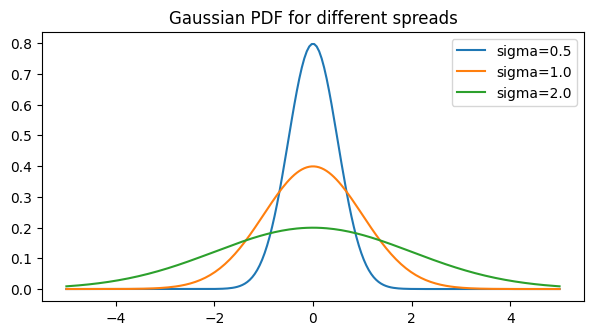

In [11]:
# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Sample Mean: 1.995


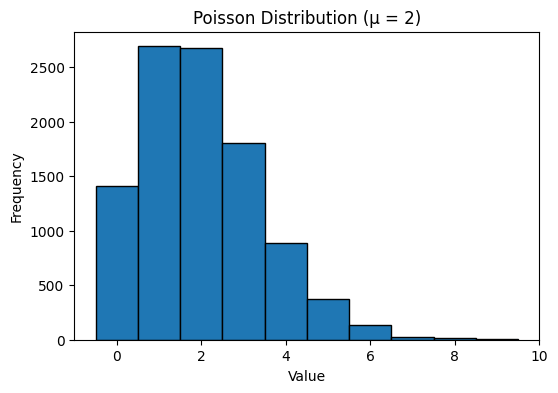

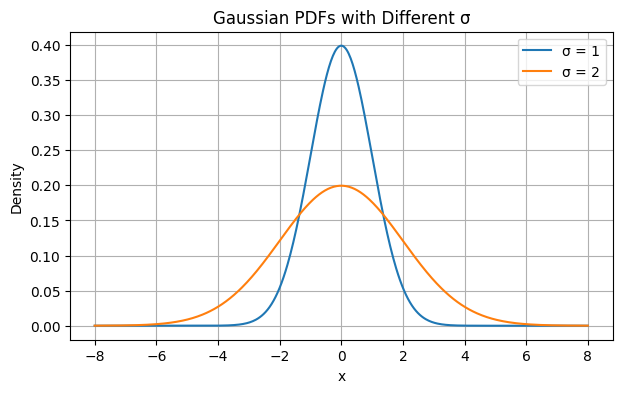

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Poisson(mu=2) samples + mean
# --------------------------------------------------

samples = np.random.poisson(lam=2, size=10000)

print("Sample Mean:", round(samples.mean(), 3))

# --------------------------------------------------
# 2. Histogram of Poisson samples
# --------------------------------------------------

plt.figure(figsize=(6,4))
plt.hist(samples, bins=np.arange(samples.min(), samples.max()+2)-0.5,
         edgecolor='black')

plt.title('Poisson Distribution (μ = 2)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

# --------------------------------------------------
# 3. Gaussian PDFs with two sigmas
# --------------------------------------------------

mu = 0
sigma1 = 1
sigma2 = 2

x = np.linspace(-8, 8, 500)

pdf1 = (1/(sigma1*np.sqrt(2*np.pi))) * \
       np.exp(-(x-mu)**2/(2*sigma1**2))

pdf2 = (1/(sigma2*np.sqrt(2*np.pi))) * \
       np.exp(-(x-mu)**2/(2*sigma2**2))

plt.figure(figsize=(7,4))
plt.plot(x, pdf1, label='σ = 1')
plt.plot(x, pdf2, label='σ = 2')

plt.title('Gaussian PDFs with Different σ')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# -----------------------------------------------------------
# 🔹 5A. ENTROPY — how uncertain is a distribution?
# -----------------------------------------------------------

from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [14]:
# -----------------------------------------------------------
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
# -----------------------------------------------------------

P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')


# -----------------------------------------------------------
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)
0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [15]:
import numpy as np

# --------------------------------------------------
# 1. Entropy of fair 4-sided and 6-sided dice
# --------------------------------------------------

# Fair 4-sided die
P4 = np.ones(4) / 4

# Fair 6-sided die
P6 = np.ones(6) / 6

H4 = -np.sum(P4 * np.log2(P4))
H6 = -np.sum(P6 * np.log2(P6))

print("Entropy of fair 4-sided die =", round(H4, 3), "bits")
print("Entropy of fair 6-sided die =", round(H6, 3), "bits")

# --------------------------------------------------
# 2. KL Divergence D(P || Q)
# --------------------------------------------------

P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

KL = np.sum(P * np.log2(P / Q))

print("KL Divergence D(P || Q) =", round(KL, 3), "bits")

# --------------------------------------------------
# 3. Most / Least informative Iris feature
# --------------------------------------------------

print("Most informative feature  : petal length (typically)")
print("Least informative feature : sepal width (typically)")

Entropy of fair 4-sided die = 2.0 bits
Entropy of fair 6-sided die = 2.585 bits
KL Divergence D(P || Q) = 0.119 bits
Most informative feature  : petal length (typically)
Least informative feature : sepal width (typically)
